# Part 5: Filtering + SVI — pseudomarginal inference with AutoMultivariateNormal

In [Part 4](04_filtering_nuts_pseudomarginal.ipynb), we used a marginal MCMC (NUTS) algorithm to infer parameters by treating the filter-based marginal likelihood as a black-box objective, avoiding explicit sampling of latent states. In this notebook, we switch to Stochastic Variational Inference (SVI), which replaces sampling-based posterior exploration with optimization of an explicit approximation to the posterior.
We use NumPyro’s AutoMultivariateNormal guide to fit a multivariate Gaussian variational distribution over the unknowns. We then compare two inference strategies under the same model and plotting setup as Part 4:
- Variational Filtering (filter-based marginal likelihood): optimize a variational posterior over parameters using the filter to marginalize latent states.
- Joint SVI (state + parameter): optimize a variational posterior over both latent states and parameters directly.

This lets us contrast the computational and statistical trade-offs between marginalizing latent states via filtering versus explicitly representing them in the variational family, while keeping the rest of the workflow (data, model, and diagnostics) consistent with [Part 4](04_filtering_nuts_pseudomarginal.ipynb).


For background on SVI in NumPyro, see [here](https://num.pyro.ai/en/latest/svi.html).

### Defining and Sampling From the Model

We return to defining and generating data from our running LTI example.

In [1]:
import jax.numpy as jnp
import jax.random as jr
import numpyro
import numpyro.distributions as dist
from numpyro.infer import Predictive

import dynestyx as dsx
from dynestyx import DiscreteTimeSimulator, DynamicalModel

# for convenience, we can define "fixed" things in the model outside of it.
# this is not required, but it helps keep the model clean.
state_dim = 2
observation_dim = 1
control_dim = 1

# Create the known matrices B, C
B = jnp.eye(state_dim, control_dim)
C = jnp.eye(observation_dim, state_dim)

# create the initial condition as a distribution
initial_condition = dist.MultivariateNormal(jnp.zeros(state_dim), jnp.eye(state_dim))


def lti_model(sigma_obs=0.1, sigma_process=0.1, obs_times=None, obs_values=None, ctrl_times=None, ctrl_values=None):
    # sample the unknown parameter
    rho = numpyro.sample("rho", dist.Uniform(-0.5, 0.5))
    A = jnp.array([[0, 0.3], [rho, -0.2]])

    # create the state evolution as a callable mapping to a distribution
    # Crucially, this depends on A, which depends on rho, which is unknown.
    # Thus, the state evolution MUST be defined within `lti_model`, not outside.
    state_evolution = lambda x, u, t_now, t_next: dist.MultivariateNormal(
        A @ x + B @ u, sigma_process**2 * jnp.eye(state_dim)
    )

    # create the observation model as a callable mapping to a distribution
    observation_model = lambda x, u, t: dist.MultivariateNormal(
        C @ x, sigma_obs**2 * jnp.eye(observation_dim)
    )

    # create the dynamical model
    dynamics = DynamicalModel(
        state_dim=state_dim,
        observation_dim=observation_dim,
        control_dim=control_dim,
        initial_condition=initial_condition,
        state_evolution=state_evolution,
        observation_model=observation_model,
    )

    # sample from the dynamical model
    return dsx.sample("f", dynamics, obs_times=obs_times, obs_values=obs_values, ctrl_times=ctrl_times, ctrl_values=ctrl_values)

In [2]:
# create a synthetic control sequence as i.i.d. Gaussians
obs_times = jnp.arange(0.0, 100.0, 1.0)  # T=100 steps
ctrl_times = obs_times  # same times for controls
ctrl_values = jr.normal(jr.PRNGKey(0), (len(ctrl_times), control_dim))
rho_true = 0.3


def make_data(sigma_obs=0.1, sigma_process=0.1):
    predictive = Predictive(
        lti_model,
        params={"rho": jnp.array(rho_true)},
        num_samples=1,
        exclude_deterministic=False,
    )
    with DiscreteTimeSimulator():
        pred = predictive(rng_key=jr.PRNGKey(0), sigma_obs=sigma_obs, sigma_process=sigma_process, obs_times=obs_times, ctrl_times=ctrl_times, ctrl_values=ctrl_values)
    obs_values = pred["observations"][0]
    return obs_times, obs_values, ctrl_times, ctrl_values


obs_times, obs_values, ctrl_times, ctrl_values = make_data(sigma_obs=0.1, sigma_process=0.1)

### Running SVI for $p(\rho \mid \text{data})$

We now perform approximate posterior inference over $\rho$ using SVI. We follow the same pattern as before: data-condition a model using a filter, then wrapping it in the correponding NumPyro inference method. We will once again compare a filter-based and joint-inference approach.

In [3]:
import optax
from numpyro.infer import SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoMultivariateNormal

from dynestyx import Filter
from dynestyx.inference.filters import EKFConfig
num_svi_steps = 1500
num_posterior_samples = 500


# Filter-based SVI (filter-based; record filtered states for latent recovery plot)
def filter_conditioned_model():
    with Filter(filter_config=EKFConfig()):
        return lti_model(obs_times=obs_times, obs_values=obs_values, ctrl_times=ctrl_times, ctrl_values=ctrl_values)


guide1 = AutoMultivariateNormal(filter_conditioned_model)
optimizer = optax.adam(learning_rate=1e-3)
svi1 = SVI(filter_conditioned_model, guide1, optimizer, loss=Trace_ELBO())
svi_result1 = svi1.run(jr.PRNGKey(1), num_steps=num_svi_steps)
posterior_1 = Predictive(
    guide1, params=svi_result1.params, num_samples=num_posterior_samples
)(jr.PRNGKey(2))


# Joint state + parameter SVI
def joint_conditioned_model():
    with DiscreteTimeSimulator():
        return lti_model(obs_times=obs_times, obs_values=obs_values, ctrl_times=ctrl_times, ctrl_values=ctrl_values)


guide2 = AutoMultivariateNormal(joint_conditioned_model)
svi2 = SVI(joint_conditioned_model, guide2, optimizer, loss=Trace_ELBO())
svi_result2 = svi2.run(jr.PRNGKey(3), num_steps=int(10 * num_svi_steps))
posterior_2_raw = Predictive(
    guide2, params=svi_result2.params, num_samples=num_posterior_samples
)(jr.PRNGKey(4))
T = len(obs_times)
posterior_2 = {"rho": posterior_2_raw["rho"]}
# _auto_latent is (num_samples, 1 + T*state_dim); first element is rho, rest are states
latent = posterior_2_raw["_auto_latent"]
posterior_2["states"] = latent[:, 1:].reshape(num_posterior_samples, T, state_dim)

100%|██████████| 15000/15000 [00:07<00:00, 2071.54it/s, init loss: 29406.1270, avg. loss [14251-15000]: -22.0897]


### Now let's compare the recovered posteriors over $\rho$

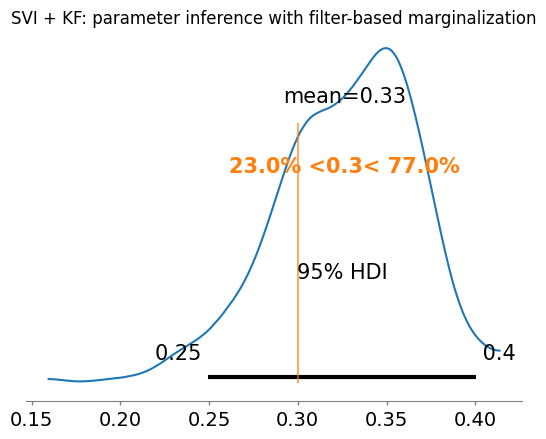

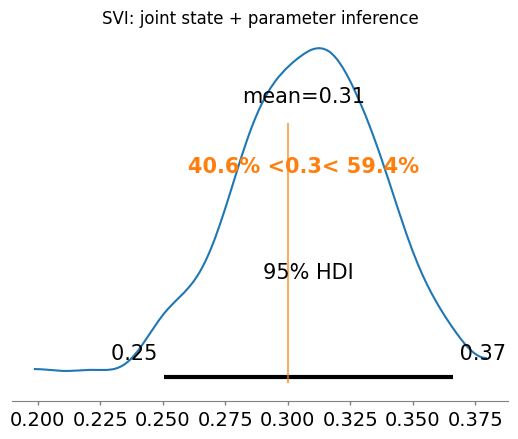

In [4]:
import arviz as az
import matplotlib.pyplot as plt

az.plot_posterior(posterior_1["rho"], hdi_prob=0.95, ref_val=rho_true)
plt.title("SVI + KF: parameter inference with filter-based marginalization")

az.plot_posterior(posterior_2["rho"], hdi_prob=0.95, ref_val=rho_true)
plt.title("SVI: joint state + parameter inference")
plt.show()

### Next, let's compare latent-state recovery

In both cases, we can also recover the posterior distribution over latent states. In the "joint" case, it comes from the SVI guide posterior (we sample states from the guide); this approximates a "smoothing" distribution. In the "pseudo-marginal" case, we run the filter at each sampled $\rho$ from the guide and store the filtered state means; this corresponds to a "filtering" distribution.

What is "smoothing" and "filtering":
- The filtering distribution at time `t`: 
    - $p(x_t \mid y_1, \dots, y_t, u_1, \dots, u_t)$,
    - only uses data up to the present
- The smoothing distribution at time `t`: 
    - $p(x_t \mid y_1, \dots, y_T, u_1, \dots, u_T)$
    - uses all available data.


In [ ]:
# Latent state recovery: 1 plot for SVI (joint), 1 for filter-based SVI
# Observed component = first state (C = [1, 0]); overlay data as scatter there.
obs_times_np = jnp.asarray(obs_times)
obs_values_np = jnp.asarray(obs_values).squeeze()  # (T,)

# Filter-based SVI: guide only has rho. Get filtered states by running the filter model at each sampled rho.
num_filter_trajectories = 100
rho_subset = posterior_1["rho"][:num_filter_trajectories]
keys = jr.split(jr.PRNGKey(5), num_filter_trajectories)
filtered_states_list = []
for i in range(num_filter_trajectories):
    out = Predictive(
        filter_conditioned_model,
        params={"rho": rho_subset[i]},
        num_samples=1,
        exclude_deterministic=False,
    )(keys[i])
    filtered_states_list.append(out["f_filtered_states_mean"][0])
posterior_1_filtered_states = jnp.stack(
    filtered_states_list, axis=0
)  # (num_filter_trajectories, T, state_dim)


def plot_latent_recovery(states_samples, title, obs_times, obs_values, state_dim=2):
    """states_samples: (num_samples, T, state_dim). One figure, one subplot per state component."""
    n_comp = state_dim
    mean_states = states_samples.mean(axis=0)  # (T, state_dim)
    lo = jnp.percentile(states_samples, 2.5, axis=0)
    hi = jnp.percentile(states_samples, 97.5, axis=0)
    fig, axes = plt.subplots(
        n_comp, 1, figsize=(7, 2.5 * n_comp), sharex=True, constrained_layout=True
    )
    if n_comp == 1:
        axes = [axes]
    for i in range(n_comp):
        ax = axes[i]
        ax.fill_between(obs_times_np, lo[:, i], hi[:, i], alpha=0.3)
        ax.plot(obs_times_np, mean_states[:, i], label=f"$x_{i}$ (mean)")
        if i == 0:  # observed component: overlay data
            ax.scatter(
                obs_times_np,
                obs_values_np,
                s=8,
                alpha=0.7,
                color="k",
                label="observations",
                zorder=3,
            )
        ax.set_ylabel(f"$x_{i}$")
        ax.legend(loc="upper right", fontsize=8)
        ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel("time")
    fig.suptitle(title)
    plt.show()


# SVI (joint): posterior over states from guide
plot_latent_recovery(
    posterior_2["states"],
    "Latent state recovery — SVI (joint state + parameter)",
    obs_times_np,
    obs_values_np,
    state_dim=state_dim,
)

# Pseudo-marginal SVI: filtered state means from KF (one per ρ sample)
plot_latent_recovery(
    posterior_1_filtered_states,
    "Latent state recovery — pseudo-marginal SVI (filter)",
    obs_times_np,
    obs_values_np,
    state_dim=state_dim,
)

**Next:** [Part 5 — SVI and warming up NUTS](../05_svi/)